# EDA template

**Copy this file to `eda-<yourname>.ipynb` before you start working in it.**
One notebook per person — merging two people's edits to the same `.ipynb`
means resolving conflicts in JSON with embedded outputs.

Clear outputs before committing.

## Setup

Paths come from the package, not from relative `../data/...` strings, so every
cell works no matter which directory the kernel was started in.

In [66]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from un_general_debate_analysis.preprocessing import (
    OUT_DIR,
    META_COLUMNS,
    merge_country_year,
    sentence_count_columns,
)
from un_general_debate_analysis.lexicons import LEXICONS

# speeches_features.csv is 56 columns wide
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"reading from {OUT_DIR}")
print(f"lexicons: {list(LEXICONS)}")

reading from /Users/b/Docs/UVA/FUDS/assignments/UN-General-Debate-Analysis/data/processed
lexicons: ['theme_trust', 'theme_transformation', 'digital_infrastructure', 'internet_and_access', 'innovation_and_technology', 'frame_promise']


## Load the data

`features` is the main table: one row per speech (= one country-year), with
metadata, text statistics, VADER sentiment, and four columns per lexicon.

`terms` is long — one row per (year, lexicon, term) — and shows *which* words
drive a trend.

In [67]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
terms = pd.read_csv(OUT_DIR / "lexicon_terms_by_year.csv")

print(f"features: {features.shape[0]:,} speeches x {features.shape[1]} columns")
print(f"terms:    {terms.shape[0]:,} rows")
print(f"years:    {features['year'].min()}-{features['year'].max()}")

# Sanity check: the full corpus is ~11k speeches. Many fewer means someone ran
# the pipeline with --limit; re-run it without one.
if len(features) < 10_000:
    print(f"\nWARNING: only {len(features):,} speeches — looks like a --limit sample.")

features: 11,141 speeches x 65 columns
terms:    6,000 rows
years:    1946-2025


In [68]:
features.head()

,country_code,country,year,session,region_name,sub_region_name,speaker_name,speaker_post,speaker_role,n_sentences,n_words,n_unique_lemmas,lexical_density,mean_sentence_length,sentiment_compound_mean,share_positive_sentences,share_negative_sentences,n_positive_sentences,n_negative_sentences,theme_trust_count,theme_trust_positive_sentences,theme_trust_negative_sentences,theme_trust_sentences,theme_transformation_count,theme_transformation_positive_sentences,theme_transformation_negative_sentences,theme_transformation_sentences,digital_infrastructure_count,digital_infrastructure_positive_sentences,digital_infrastructure_negative_sentences,digital_infrastructure_sentences,internet_and_access_count,internet_and_access_positive_sentences,internet_and_access_negative_sentences,internet_and_access_sentences,innovation_and_technology_count,innovation_and_technology_positive_sentences,innovation_and_technology_negative_sentences,innovation_and_technology_sentences,frame_promise_count,frame_promise_positive_sentences,frame_promise_negative_sentences,frame_promise_sentences,theme_trust,theme_trust_sentiment,theme_transformation,theme_transformation_sentiment,digital_infrastructure,digital_infrastructure_sentiment,internet_and_access,internet_and_access_sentiment,innovation_and_technology,innovation_and_technology_sentiment,frame_promise,frame_promise_sentiment,technology_frame_promise,technology_frame_promise_sentences,technology_frame_promise_sentiment,technology_frame_peril,technology_frame_peril_sentences,technology_frame_peril_sentiment,technology_theme_trust,technology_theme_trust_sentences,technology_theme_trust_sentiment,term_counts
0,ARG,Argentina,1946,1,Americas,Latin America and the Caribbean,Mr. Arce,NaN,unknown,127,3305,943,0.485023,26.023622,0.260215,0.590551,0.204724,75,26,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,12,3,16,1,0.90620,0,0.0000,0,0.0000,0,0.0,0,0.0000,1,0.379394,0,0,0.0,0,0,0.0,0,0,0.0,"{""good faith"": 1, ""hope"": 2, ""improve"": 2, ""im..."
1,AUS,Australia,1946,1,Oceania,Australia and New Zealand,Mr. Makin,NaN,unknown,125,4475,911,0.495866,35.800000,0.392232,0.720000,0.136000,90,17,4,4,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,14,4,18,1,0.89285,0,0.0000,0,0.0000,0,0.0,0,0.0000,1,0.486867,0,0,0.0,0,0,0.0,0,0,0.0,"{""accelerate"": 1, ""achievement"": 1, ""advance"":..."
2,BEL,Belgium,1946,1,Europe,Western Europe,Mr. Van Langenhove,NaN,unknown,98,2479,688,0.482453,25.295918,0.229380,0.581633,0.214286,57,21,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,0,1,9,6,1,7,0,0.00000,1,0.6486,0,0.0000,0,0.0,1,0.6486,1,0.629829,0,0,0.0,0,0,0.0,0,0,0.0,"{""benefit"": 2, ""efficiency"": 1, ""hope"": 1, ""in..."
3,BLR,Belarus,1946,1,Europe,Eastern Europe,Mr. Kiselev,NaN,unknown,98,3011,803,0.521089,30.724490,0.233941,0.622449,0.295918,61,29,3,3,0,3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,9,7,0,8,1,0.86990,0,0.0000,1,0.5106,0,0.0,0,0.0000,1,0.645138,0,0,0.0,0,0,0.0,0,0,0.0,"{""confidence"": 1, ""hope"": 3, ""progress"": 2, ""s..."
4,BOL,Bolivia (Plurinational State of),1946,1,Americas,Latin America and the Caribbean,Mr. Costa du Rels,NaN,unknown,55,1445,545,0.480969,26.272727,0.251342,0.563636,0.181818,31,10,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0,3,1,0.86580,0,0.0000,0,0.0000,0,0.0,0,0.0000,1,0.773533,0,0,0.0,0,0,0.0,0,0,0.0,"{""confidence"": 1, ""hope"": 3}"


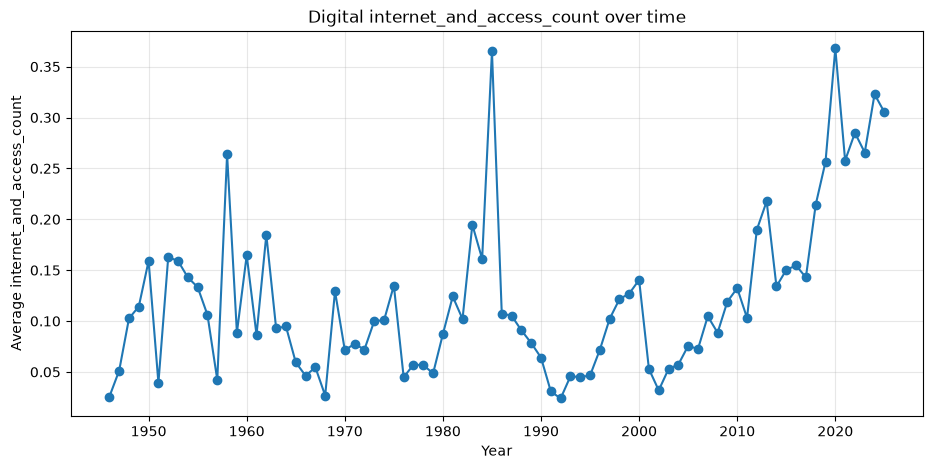

In [69]:
digital_by_year = features.groupby("year")["digital_infrastructure_count"].mean()

digital_by_year.plot(figsize=(11, 5), marker="o")
plt.xlabel("Year")
plt.ylabel("Average internet_and_access_count")
plt.title("Digital internet_and_access_count over time")
plt.grid(alpha=0.3)
plt.show()

### The text, loaded separately

`speeches_text.csv.gz` holds the cleaned text and the lemmatised, stop-word-free
tokens of every speech. It is a few hundred MB in memory for the full corpus, so
only load it when you actually need it (TF-IDF, topic models, word clouds).

In [70]:
import json
import pandas as pd



# Inspect one row
sample = df.iloc[0]["term_counts"]
print(json.dumps(sample, indent=2))

{
  "good faith": 1,
  "hope": 2,
  "improve": 2,
  "improvement": 1,
  "optimism": 1,
  "progress": 1,
  "promise": 3,
  "solution": 6
}


In [71]:
# texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz")
# texts.head()

### `term_counts` is a JSON string

Parse it with `json.loads` (not `ast.literal_eval`) to get the per-term counts
for a single speech.

In [72]:
example = features.iloc[0]
print(f"{example['country']}, {example['year']}")
json.loads(example["term_counts"])

Argentina, 1946


{'good faith': 1,
 'hope': 2,
 'improve': 2,
 'improvement': 1,
 'optimism': 1,
 'progress': 1,
 'promise': 3,
 'solution': 6}

## Normalise before comparing

Speech length varies enormously across the corpus, and so does the number of
countries speaking each year (~50 in 1946, ~190 today). Raw counts are not
comparable across speeches or across years — always divide first.

- word counts (`<lexicon>_count`) by `n_words`
- sentence counts (`<lexicon>_sentences`) by `n_sentences`

In [73]:
rates = features[META_COLUMNS[:4]].copy()
for lexicon in LEXICONS:
    rates[f"{lexicon}_per_1k_words"] = (
        1_000 * features[f"{lexicon}_count"] / features["n_words"]
    )

rates.groupby("year")[[f"{lex}_per_1k_words" for lex in LEXICONS]].mean().tail()

,theme_trust_per_1k_words,theme_transformation_per_1k_words,digital_infrastructure_per_1k_words,internet_and_access_per_1k_words,innovation_and_technology_per_1k_words,frame_promise_per_1k_words
year,,,,,,
2021,1.124144,2.120984,0.127375,0.231317,0.705932,6.748689
2022,1.307592,2.254129,0.142690,0.220988,0.575889,6.226275
2023,2.150253,2.224662,0.140740,0.172822,0.903779,7.153874
2024,1.612256,2.693636,0.164785,0.180347,1.021045,6.812715
2025,1.785045,2.429978,0.156940,0.146350,1.075500,6.641864


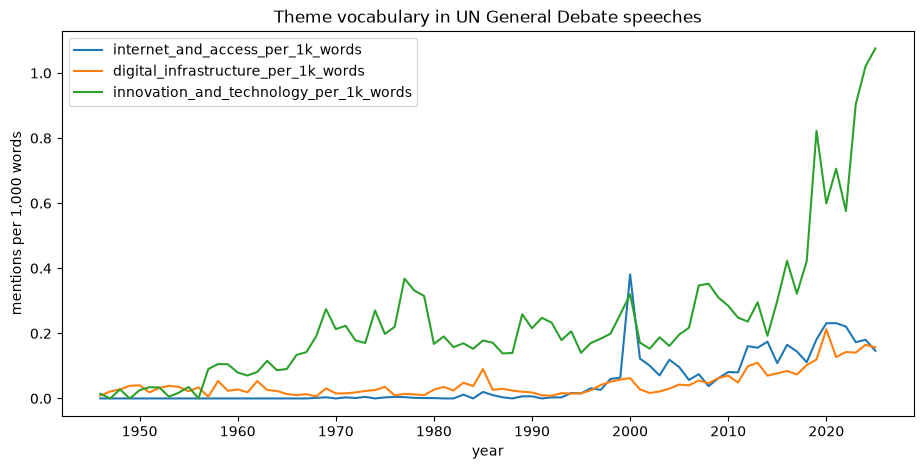

In [74]:
# A first look: how much the themes are talked about over time
yearly = rates.groupby("year")[
    ["internet_and_access_per_1k_words",'digital_infrastructure_per_1k_words','innovation_and_technology_per_1k_words']
].mean()

yearly.plot(figsize=(11, 5))
plt.ylabel("mentions per 1,000 words")
plt.xlabel("year")
plt.title("Theme vocabulary in UN General Debate speeches")
plt.show()

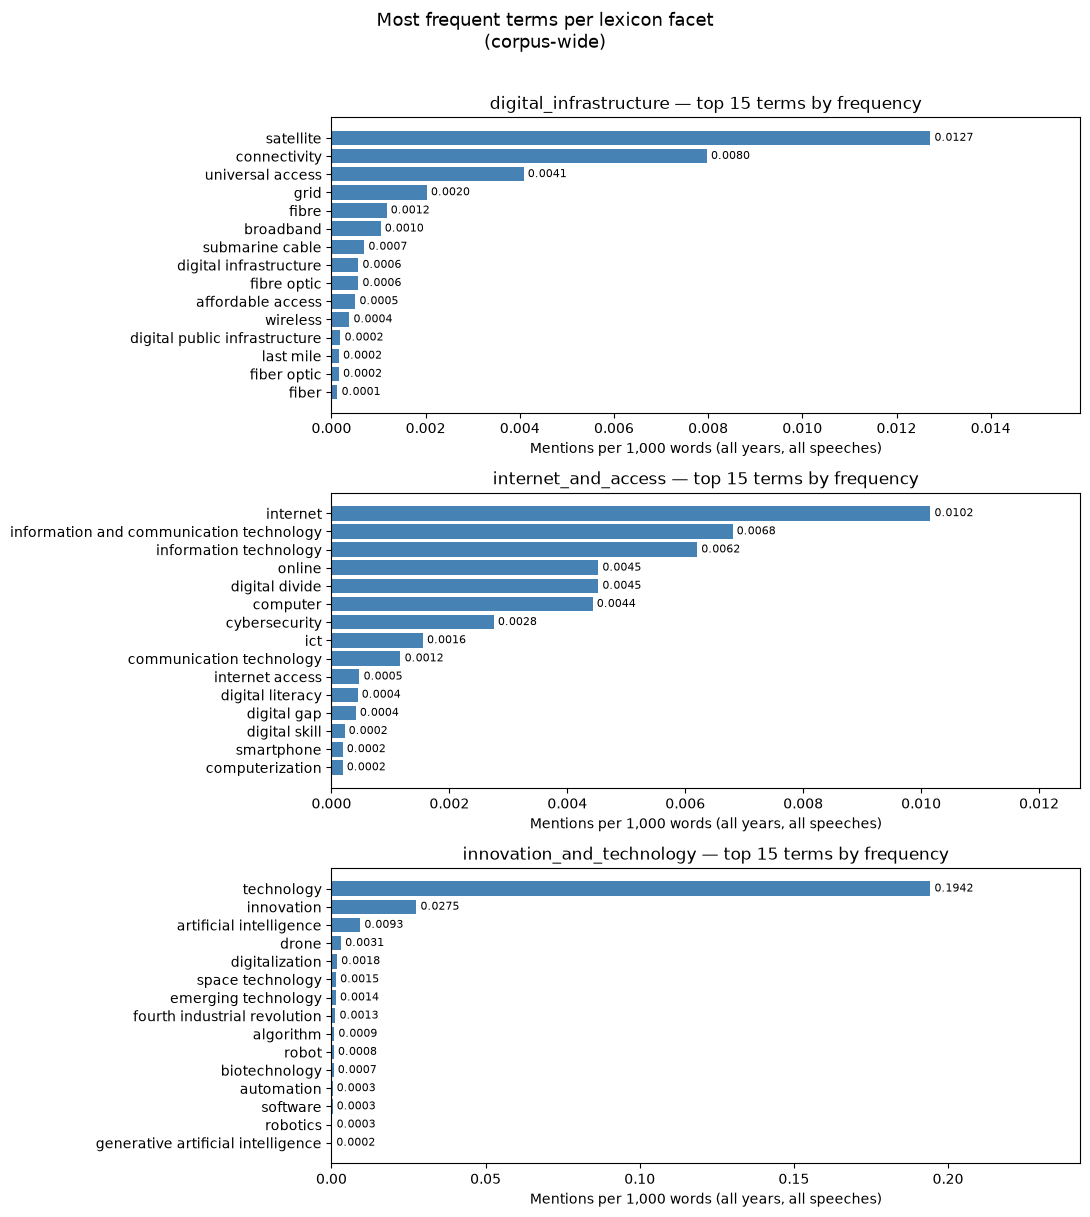


Term                                          Facet                               Per 1k words
----------------------------------------------------------------------------------------------
technology                                    innovation_and_technology                0.19424
innovation                                    innovation_and_technology                0.02752
satellite                                     digital_infrastructure                   0.01272
internet                                      internet_and_access                      0.01016
artificial intelligence                       innovation_and_technology                0.00933
connectivity                                  digital_infrastructure                   0.00797
information and communication technology      internet_and_access                      0.00680
information technology                        internet_and_access                      0.00620
digital divide                                int

In [76]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---------------------------------------------------------------
df = pd.read_csv(OUT_DIR / "speeches_features.csv")
df["term_counts"] = df["term_counts"].apply(json.loads)

# --- Import facets -----------------------------------------------------------
from un_general_debate_analysis.lexicons import TECH_FACETS

# Build term → facet lookup
term_to_facet = {
    term: facet
    for facet, terms in TECH_FACETS.items()
    for term in terms
}
digital_terms = set(term_to_facet.keys())

# --- Aggregate term counts across all speeches ------------------------------
total_words = df["n_words"].sum()

term_totals: dict[str, int] = {}
for counts in df["term_counts"]:
    for term, count in counts.items():
        if term in digital_terms:
            term_totals[term] = term_totals.get(term, 0) + count

# Normalise to per 1,000 words
term_norm = {
    term: (count / total_words) * 1000
    for term, count in term_totals.items()
}

# --- Build a DataFrame for easy plotting ------------------------------------
term_df = pd.DataFrame([
    {"term": term, "facet": term_to_facet[term], "per_1k_words": score}
    for term, score in term_norm.items()
]).sort_values("per_1k_words", ascending=False)

# --- Plot: top 15 terms per facet -------------------------------------------
facets = list(TECH_FACETS.keys())
n_facets = len(facets)

fig, axes = plt.subplots(n_facets, 1, figsize=(11, 4 * n_facets))
if n_facets == 1:
    axes = [axes]

for ax, facet in zip(axes, facets):
    facet_df = (
        term_df[term_df["facet"] == facet]
        .nlargest(15, "per_1k_words")
        .sort_values("per_1k_words", ascending=True)
    )

    if facet_df.empty:
        ax.set_title(f"{facet} — no terms found")
        continue

    bars = ax.barh(facet_df["term"], facet_df["per_1k_words"], color="steelblue")
    ax.set_xlabel("Mentions per 1,000 words (all years, all speeches)")
    ax.set_title(f"{facet} — top {len(facet_df)} terms by frequency")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xlim(0, facet_df["per_1k_words"].max() * 1.25)

plt.suptitle("Most frequent terms per lexicon facet\n(corpus-wide)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("diagnostics_top_terms_per_facet.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Print table ------------------------------------------------------------
print(f"\n{'Term':<45} {'Facet':<35} {'Per 1k words':>12}")
print("-" * 94)
for _, row in term_df.iterrows():
    print(f"{row['term']:<45} {row['facet']:<35} {row['per_1k_words']:>12.5f}")


## Bringing in an external dataset

`merge_country_year` joins on `(country_code, year)` with ISO-3166 alpha-3 codes.
Its defaults match Our World in Data exports (`Entity`, `Code`, `Year`); pass
`country_col` / `year_col` for anything else.

Remember the corpus contains states that no longer exist (`CSK`, `DDR`, `YUG`,
`YMD`) plus `EU`, which external datasets usually lack — expect NaNs there.

In [42]:
owid = pd.read_csv("../data/external/worldbank_EG.USE.PCAP.KG.OE.csv")
df = merge_country_year(features, owid)
#
# happiness = pd.read_csv("../data/external/happiness.csv")
# df = merge_country_year(features, happiness, country_col="iso3", year_col="year")
#
# print(f"matched {df['<indicator>'].notna().sum():,} of {len(df):,} speeches")

## Your analysis below

Two reminders from the brief:

- Session 80 (2025) was transcribed from interpretation audio, not official
  transcripts. Be careful reading a 2025 "trend" as real.
- `speaker_role` is `unknown` for many pre-1994 speeches; the UN records do not
  consistently give the speaker's post before then.

In [ ]:
def search_speeches(session_start, session_end, words):
    patterns = {
        word: re.compile(rf"(?<!\w){re.escape(word)}(?!\w)", re.IGNORECASE)
        for word in words
    }

    records = []
    occurrences = []

    for path in RAW_DIR.rglob("*.txt"):
        match = re.search(
            r"session[\s_-]*(\d+)[\s_-]+(19|20)\d{2}",
            str(path),
            re.IGNORECASE,
        )

        if not match:
            continue

        session = int(match.group(1))
        if not session_start <= session <= session_end:
            continue

        year_match = re.search(r"\b(19|20)\d{2}\b", str(path))
        if not year_match:
            continue

        year = int(year_match.group())
        text = path.read_text(encoding="utf-8", errors="ignore")

        records.append({
            "session": session,
            "year": year,
            "file": path.name,
            **{word: len(pattern.findall(text)) for word, pattern in patterns.items()},
        })

        sentences = re.split(r"(?<=[.!?])\s+", text.strip())

        for sentence in sentences:
            for word, pattern in patterns.items():
                if pattern.search(sentence):
                    occurrences.append({
                        "session": session,
                        "year": year,
                        "file": path.name,
                        "word": word,
                        "sentence": sentence.strip(),
                    })

    counts = pd.DataFrame(records)

    if not counts.empty:
        counts_by_year = (
            counts.groupby("year")[words]
            .sum()
            .sort_index()
        )
    else:
        counts_by_year = pd.DataFrame(columns=words)

    occurrences_df = pd.DataFrame(occurrences)

    return counts_by_year, occurrences_df


Counts by year:


,iphone,phone,cell phone,mobile
year,,,,
2010,0,3,0,5
2011,0,2,0,2
2012,0,4,2,5
2013,0,5,1,6
2014,0,4,1,2
2025,0,3,0,1



Matching sentences:


,year,file,term,sentence
14,2010,ISR_65_2010.txt,phone,"When I arrived yesterday \nin New York, I received a phone call from the chairman \nof one of the Jewish organizations, who asked me how \nI was coping with all the pressure that is being placed \non Israel."
19,2010,SEN_65_2010.txt,mobile,"That requires only very little equipment, such as \na mobile phone."
18,2010,SEN_65_2010.txt,phone,"That requires only very little equipment, such as \na mobile phone."
12,2010,SGP_65_2010.txt,mobile,"One of the most important developments in the \nworld today is the widespread availability of cheap \nmobile phones, often with built-in cameras."
13,2010,SGP_65_2010.txt,mobile,Mobile \nphones have altered traditional power relationships \neverywhere where they are available.
16,2010,UGA_65_2010.txt,mobile,"The study by the \nMcKinsey Global Institute revealed that there are now \n316 million new mobile phone subscribers since the \nyear 2000 in Africa, more than the entire population of \nthe United States."
17,2010,UGA_65_2010.txt,mobile,"In other words, there are now more \nmobile phones in Africa than there are American \npeople living in the United States."
15,2010,UGA_65_2010.txt,phone,"The study by the \nMcKinsey Global Institute revealed that there are now \n316 million new mobile phone subscribers since the \nyear 2000 in Africa, more than the entire population of \nthe United States."
24,2011,MDA_66_2011.txt,phone,Another important objective is \nthe restoration of landline phone connections to allow \npeople from the Transnistrian region to communicate \nfreely with their relatives and friends in the rest of \nMoldova.
26,2011,SWE_66_2011.txt,mobile,In one minute I can use my mobile phone to get hold of \na friend on the other side of the globe or my children \nback home in Sweden.


In [80]:
sentences


['I bring the warm greetings of His Majesty the King and from the people of Bhutan.',
 'Allow me to convey our congratulations to His Excellency Mr.',
 'Csaba Korosi, President of General Assembly at its seventy-seventh session.',
 'He may rest assured of Bhutan’s full support as he steers us through the session.',
 'I also take this opportunity to convey our gratitude and admiration to His Excellency Mr.',
 'Abdulla Shahid, President of the Assembly at its seventy-sixth session, for the exceptional manner in which he guided our work this past tumultuous year.',
 'Our appreciation is also due to Secretary-General Antonio Guterres, who, in a most challenging year for our Organization, coinciding with the first year of his second term, has continued to serve as a compelling and valiant advocate for peace, people and planet.',
 'I arrived in New York last week with a vastly different prepared text for delivery today.',
 'In recent days, however, I received a heartfelt appeal from Chimi, a